## PROBLEM STATEMENT

***DATASET:*** https://www.kaggle.com/datasets/nancyalaswad90/lung-cancer

The effectiveness of cancer prediction system helps the people to know their cancer risk with low cost and it also helps the people to take the appropriate decision based on their cancer risk status. 

- **Total no. of attributes:** 16 
- **No .of instances:** 284 
- **Attribute information:**
  * 1. **Gender:** M(male), F(female)
  * 2. **Age:** Age of the patient
  * 3. **Smoking:** YES=2 , NO=1.
  * 4. **Yellow fingers:** YES=2 , NO=1.
  * 5. **Anxiety:** YES=2 , NO=1.
  * 6. **Peer_pressure:** YES=2 , NO=1.
  * 7. **Chronic Disease:** YES=2 , NO=1.
  * 8. **Fatigue:** YES=2 , NO=1.
  * 9. **Allergy:** YES=2 , NO=1.
  * 10. **Wheezing:** YES=2 , NO=1.
  * 11. **Alcohol:** YES=2 , NO=1.
  * 12. **Coughing:** YES=2 , NO=1.
  * 13. **Shortness of Breath:** YES=2 , NO=1.
  * 14. **Swallowing Difficulty:** YES=2 , NO=1.
  * 15. **Chest pain:** YES=2 , NO=1.
  * 16. **TARGET**: Lung Cancer: YES , NO.

In [134]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [12]:
#Load the dataset
data = pd.read_csv("C:\\Users\\rache\\OneDrive\\Rachel Study Materials\\Excel\\survey lung cancer.csv")

In [14]:
#Top 5 rows
data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [16]:
# Information of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [18]:
# Data Description
data.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


The dataset is preprocessed, no need for handling missing values or data cleaning

In [21]:
# Null Values
data.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

There is no null values in this dataset 

#### DATA VISUALIZATION

Text(0.5, 1.0, 'Analyze Gender count has Lung Cancer')

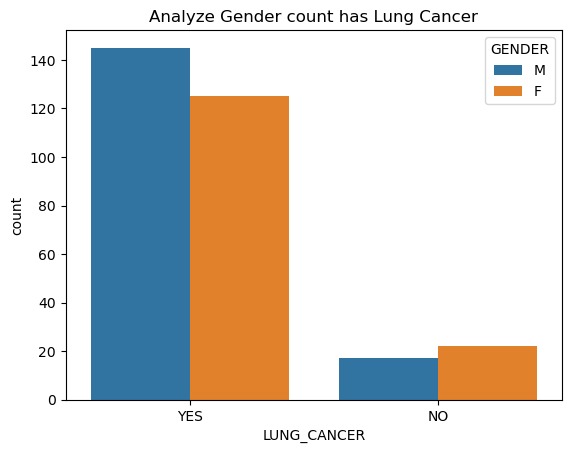

In [38]:
sns.countplot(x = "LUNG_CANCER", hue = "GENDER", data = data)
plt.title("Analyze Gender count has Lung Cancer")

Majority people who have Lung cancer risk is **Male** compared to Female.

C:\Users\rache\AppData\Local\Temp\ipykernel_29640\76249059.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:g'` for the same effect.

  sns.swarmplot(x = "LUNG_CANCER", y = "AGE", hue = "GENDER", color = "g", data = data)


Text(0.5, 1.0, 'Analyze most common age has risk of Lung Cancer')

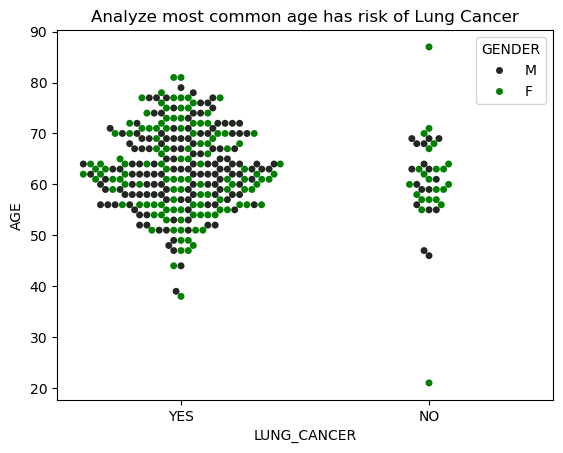

In [75]:
# Lets analyze which age group have high lung cancer risk
sns.swarmplot(x = "LUNG_CANCER", y = "AGE", hue = "GENDER", color = "g", data = data)
plt.title("Analyze most common age has risk of Lung Cancer")

Most of the people around **55 to 70** age has Lung cancer.

Text(0.5, 1.0, 'Average Age of Lung Cancer patients who gets chest pain has Anxiety')

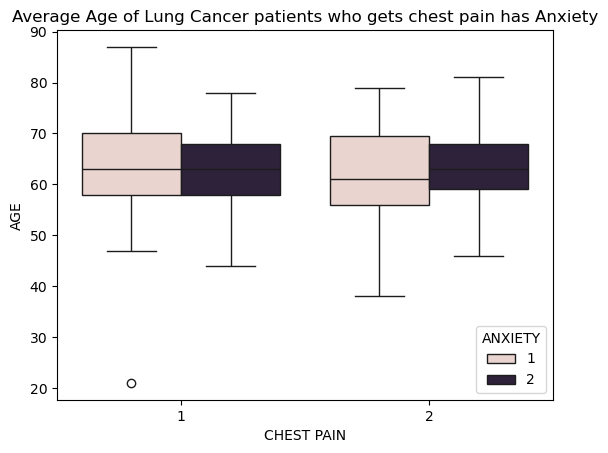

In [83]:
sns.boxplot(x = "CHEST PAIN", y = "AGE", hue = "ANXIETY", data = data)
plt.title("Average Age of Lung Cancer patients who gets chest pain has Anxiety")

Patients Around Age from **60 - 70** gets Anxiety has chest pain

## DATA TRANSFORMATION

Let's Transform the Target variable **LUNG_CANCER** into binary for Model Training

In [96]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['GENDER'] = le.fit_transform(data['GENDER'])
data['LUNG_CANCER'] = le.fit_transform(data['LUNG_CANCER'])

data.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


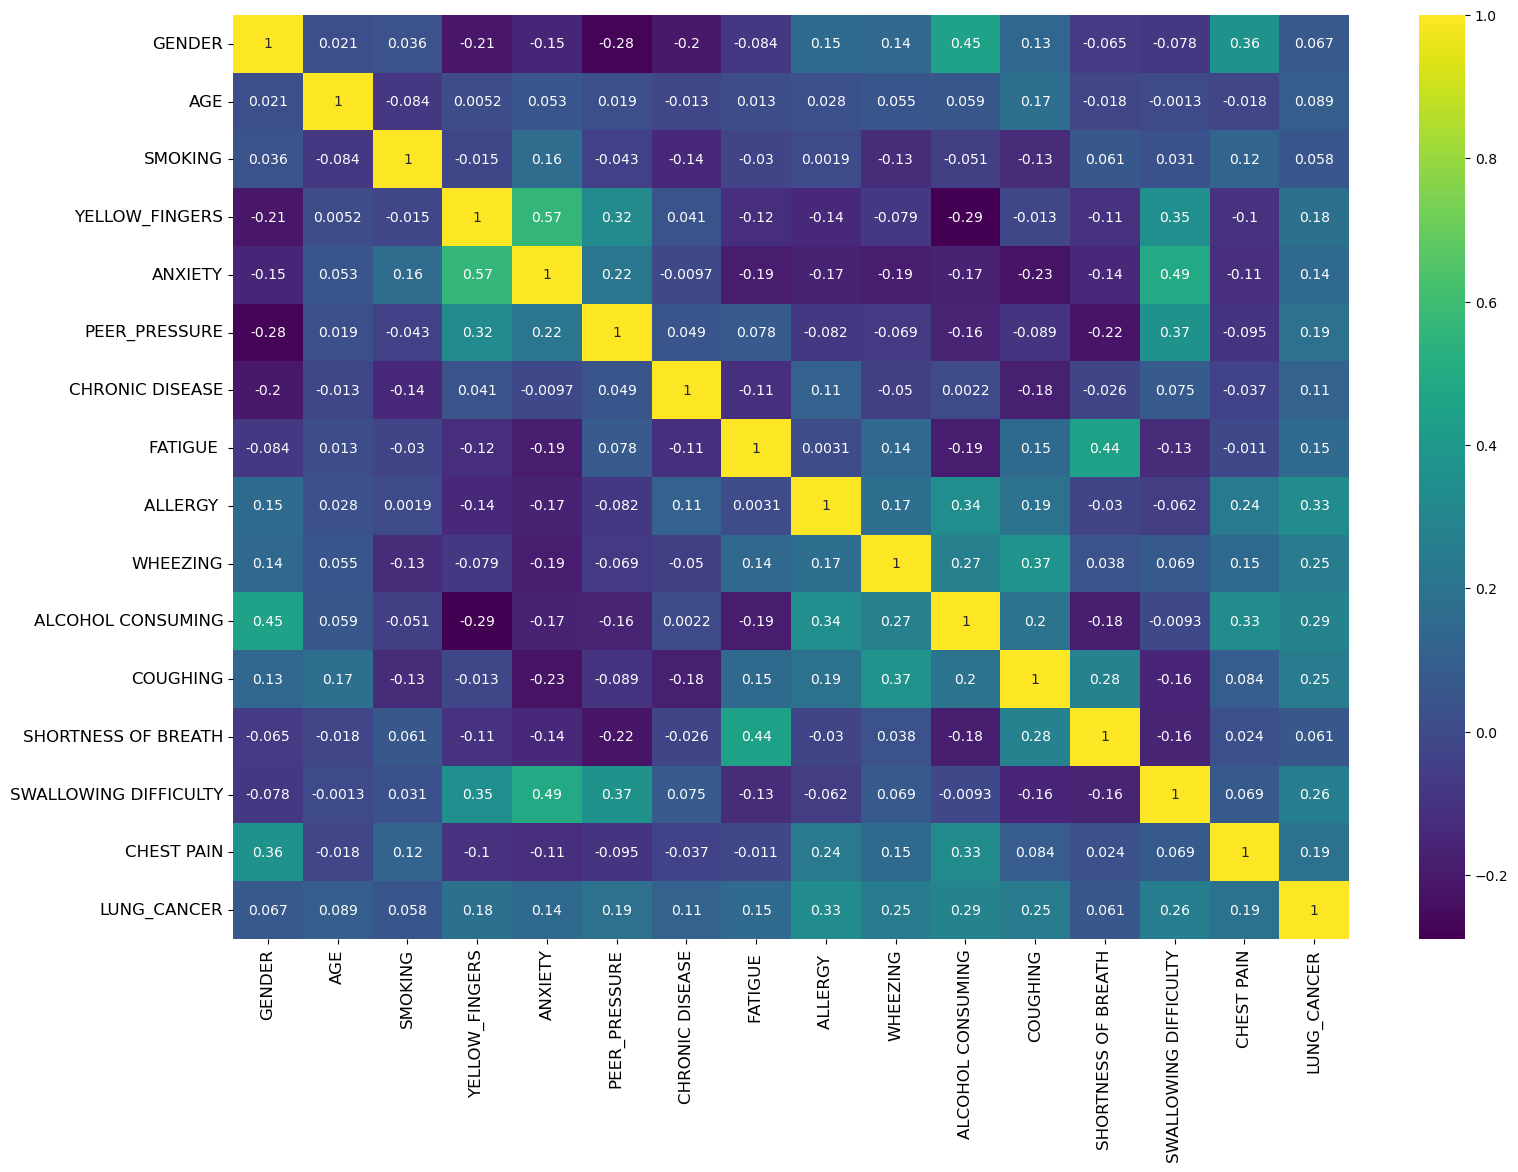

In [110]:
# Multicollinearity
corr = data.corr()
plt.figure(figsize=(18, 12))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 10},
    cmap='viridis'
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()



There is no Multicollinearity problem in this dataset

In [113]:
# Model Training
x = data.drop('LUNG_CANCER', axis = 1)
y = data[['LUNG_CANCER']]

### Feature Scaling

In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_Scaled = scaler.fit_transform(x)

In [118]:
X_train, X_test, y_train, y_test = train_test_split(X_Scaled, y, test_size = 0.3, random_state = 42)

In [158]:
#LogisticRegression
LR = LogisticRegression(class_weight='balanced')

In [160]:
LR.fit(X_train, y_train)

C:\Users\rache\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [162]:
y_pred = LR.predict(X_test)

In [164]:
print("Confusion Matrix for Logistic Regression:")
print(confusion_matrix(y_test,y_pred))

Confusion Matrix for Logistic Regression:
[[ 6  1]
 [ 6 80]]


In [166]:
print("Training Accuracy Score:", accuracy_score(y_train, LR.predict(X_train)))
print("Testing Accuracy Score:", accuracy_score(y_test, y_pred))

Training Accuracy Score: 0.8981481481481481
Testing Accuracy Score: 0.9247311827956989


In [168]:
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.50      0.86      0.63         7
           1       0.99      0.93      0.96        86

    accuracy                           0.92        93
   macro avg       0.74      0.89      0.79        93
weighted avg       0.95      0.92      0.93        93



In [170]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LR, x, y, cv=5)
print("CV Mean Accuracy:", cv_scores.mean())

C:\Users\rache\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\rache\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\rache\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:

CV Mean Accuracy: 0.8804865150713906


C:\Users\rache\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\rache\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\rache\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration

In [172]:
print(classification_report(y_train, LR.predict(X_train)))

              precision    recall  f1-score   support

           0       0.60      0.97      0.74        32
           1       0.99      0.89      0.94       184

    accuracy                           0.90       216
   macro avg       0.80      0.93      0.84       216
weighted avg       0.93      0.90      0.91       216

